In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
df = pd.read_csv("D:/DataAnalystPortfolioProject_PBI_SQL_Python_MarketingAnalytics-main/online_retail_II.csv")

In [3]:
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/2010 8:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/2010 8:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
9,536368,22960,JAM MAKING SET WITH JARS,6,12/1/2010 8:34,4.25,13047.0,United Kingdom


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      541910 non-null  object 
 1   StockCode    541910 non-null  object 
 2   Description  540456 non-null  object 
 3   Quantity     541910 non-null  int64  
 4   InvoiceDate  541910 non-null  object 
 5   Price        541910 non-null  float64
 6   Customer ID  406830 non-null  float64
 7   Country      541910 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [5]:
df_clean = df.dropna(subset='Customer ID').copy()

In [6]:
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['Customer ID'] = df_clean['Customer ID'].astype(int)
df_clean['Invoice'] = df_clean['Invoice'].astype(str)
df_clean = df_clean[(df_clean['Quantity']>0) & (df_clean['Price'] > 0)]
df_clean['Total Sales'] = df_clean['Quantity'] * df_clean["Price"]

In [7]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397885 entries, 0 to 541909
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      397885 non-null  object        
 1   StockCode    397885 non-null  object        
 2   Description  397885 non-null  object        
 3   Quantity     397885 non-null  int64         
 4   InvoiceDate  397885 non-null  datetime64[ns]
 5   Price        397885 non-null  float64       
 6   Customer ID  397885 non-null  int64         
 7   Country      397885 non-null  object        
 8   Total Sales  397885 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 30.4+ MB


In [8]:
# 10 sản phẩm bán chạy nhất theo doanh thu 

In [27]:
total_revenue = df_clean["Total Sales"].sum()
total_orders = df_clean["Invoice"].nunique()
total_customers = df_clean["Customer ID"].nunique()
print(f'Tổng doanh thu:', total_revenue,
      f'Tổng đơn hàng:', total_orders,
f'Tổng khách hàng:', total_customers)


Tổng doanh thu: 8911425.904 Tổng đơn hàng: 18532 Tổng khách hàng: 4338


In [10]:
top_10_product = df_clean.groupby('Description')['Total Sales'].sum().sort_values(ascending=False).head(10).reset_index()
print(top_10_product)

                          Description  Total Sales
0         PAPER CRAFT , LITTLE BIRDIE    168469.60
1            REGENCY CAKESTAND 3 TIER    142592.95
2  WHITE HANGING HEART T-LIGHT HOLDER    100448.15
3             JUMBO BAG RED RETROSPOT     85220.78
4      MEDIUM CERAMIC TOP STORAGE JAR     81416.73
5                             POSTAGE     77821.96
6                       PARTY BUNTING     68844.33
7       ASSORTED COLOUR BIRD ORNAMENT     56580.34
8                              Manual     53779.93
9                  RABBIT NIGHT LIGHT     51346.20


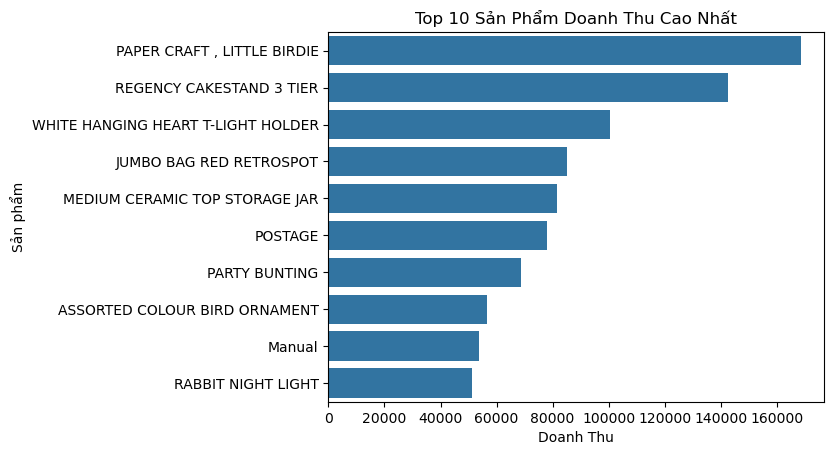

In [11]:
sns.barplot(x='Total Sales', y='Description', data= top_10_product)
plt.title('Top 10 Sản Phẩm Doanh Thu Cao Nhất')
plt.xlabel('Doanh Thu')
plt.ylabel('Sản phẩm')
plt.show()

In [12]:
# PAPER CRAFT , LITTLE BIRDIE và REGENCY CAKESTAND 3 TIER đóng góp doanh thu lớn nhất

In [13]:
top_5_countries = df_clean.groupby('Country')["Total Sales"].sum().sort_values(ascending=False).head(5).reset_index()
print(top_5_countries)

          Country  Total Sales
0  United Kingdom  7308391.554
1     Netherlands   285446.340
2            EIRE   265545.900
3         Germany   228867.140
4          France   209042.050


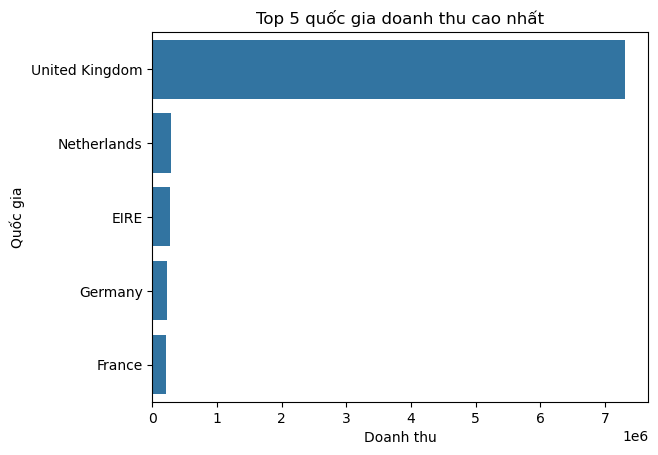

In [14]:
sns.barplot(x='Total Sales', y='Country', data = top_5_countries) 
plt.title('Top 5 quốc gia doanh thu cao nhất')
plt.xlabel('Doanh thu')
plt.ylabel('Quốc gia')
plt.show()

In [15]:
#Doanh nghiệp đang phụ thuộc gần như tuyệt đối vào thị trường nội địa UK. Mọi chiến dịch Marketing/Ops chính nên tập trung tối ưu tại UK, trong khi các nước Châu Âu khác là thị trường tiềm năng cần chiến lược mở rộng riêng.

In [16]:
df_clean["Month"] = df_clean['InvoiceDate'].dt.month
monthly_sales = df_clean.groupby("Month")["Total Sales"].sum().reset_index()
print(monthly_sales)


    Month  Total Sales
0       1   569445.040
1       2   447137.350
2       3   595500.760
3       4   469200.361
4       5   678594.560
5       6   661213.690
6       7   600091.011
7       8   645343.900
8       9   952838.382
9      10  1039318.790
10     11  1161817.380
11     12  1090924.680


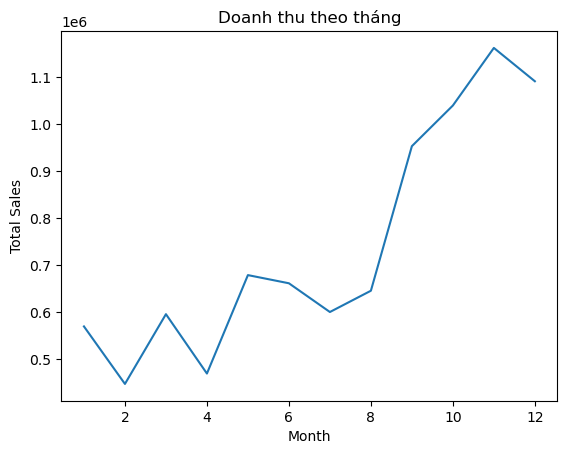

In [17]:
sns.lineplot(x='Month',y='Total Sales',data=monthly_sales)
plt.title('Doanh thu theo tháng')
plt.show()


In [18]:
# Tháng 11 có doanh thu cao nhất trong năm

In [19]:
import datetime as dt 
snapshot_date = df_clean['InvoiceDate'].max() + dt.timedelta(days=1)
rfm = df_clean.groupby('Customer ID').agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days, 
    "Invoice": 'nunique',
    'Total Sales': 'sum'}).reset_index()
rfm.columns = ['Customer ID', 'Recency', 'Frequency', 'Monetary']
rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [20]:
rfm['R_score'] = pd.qcut(rfm['Recency'], q=5, labels=[5,4,3,2,1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5]).astype(int)
rfm['M_score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1,2,3,4,5]).astype(int)
rfm['Segment'] = rfm['R_score'].astype(str)+rfm['F_score'].astype(str)+rfm['M_score'].astype(str)
rfm['RFM_Score'] = rfm[['R_score','F_score','M_score']].sum(axis=1)
rfm.head(10)
                         
                         

,Customer ID,Recency,Frequency,Monetary,R_score,F_score,M_score,Segment,RFM_Score
0,12346,326,1,77183.60,1,1,5,115,7
1,12347,2,7,4310.00,5,5,5,555,15
2,12348,75,4,1797.24,2,4,4,244,10
3,12349,19,1,1757.55,4,1,4,414,9
4,12350,310,1,334.40,1,1,2,112,4
5,12352,36,8,2506.04,3,5,5,355,13
6,12353,204,1,89.00,1,1,1,111,3
7,12354,232,1,1079.40,1,1,4,114,6
8,12355,214,1,459.40,1,1,2,112,4
9,12356,23,3,2811.43,4,3,5,435,12


In [21]:
seg_map = {f'[1-2][1-2]': 'Hibernating', f'[1-2][3-4]': 'At risk', f'[1-2]5': 'Can\'t Loose Them', f'3[1-2]': 'About To Sleep', f'33': 'Need Attention', f'[3-4][4-5]': 'Loyal Customers', f'41': 'Promising', f'51': 'New Customers', f'[4-5][2-3]': 'Potential Loyalist', f'5[4-5]': 'Champions'
}
rfm['Segment']=rfm['R_score'].astype(str)+rfm['F_score'].astype(str)
rfm['Segment']=rfm['Segment'].replace(seg_map,regex=True)




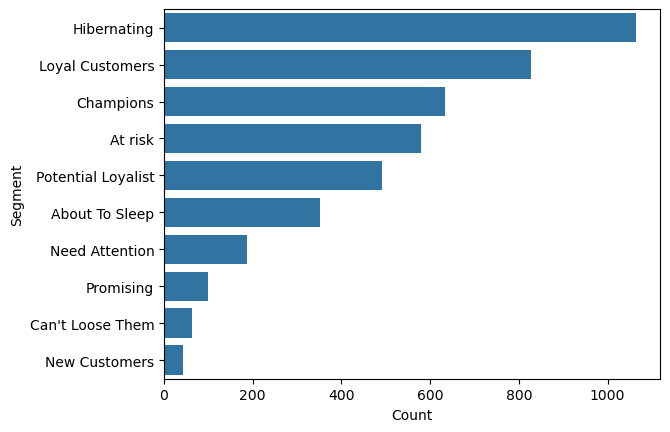

In [22]:
segment_counts = rfm['Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment','Count']
sns.barplot(x='Count',y='Segment',data=segment_counts)
plt.show()

In [23]:
#Nhóm Loyal Customers và Champions vẫn ở mức cao, đóng góp doanh thu bền vững
#Nhóm Hibernating là đông nhất, cộng với nhóm About to sleep thì nhóm khác có nguy cơ rời doanh nghiệp là lớn 
#Tỉ lệ khách hàng mới là ít, cho thấy doanh nghiệp ít tập trung vào thu hút khách hàng mới mà chỉ giữ chân khách cũ

In [25]:
df_clean.to_csv('online_retail_clean.csv', index=False)

In [26]:
rfm.to_csv('rfm_segmented.csv', index=False)